##
# <center> Bakery Dataset Data Mining - Spring 2026
## <center> Created By: Saba Berenji

# Descriptive Summary

This dataset is obtained from a Kaggle repository called Transactions from a bakery (https://www.kaggle.com/datasets/sulmansarwar/transactions-from-a-bakery?resource=download). The dataset contains 21,293 samples from a bakery across four  variables: Date, Time, Transaction, and Item.

The raw data was first loaded into a Relational Database System (SQL) and then queried, and cleaned to remove invalid entries like "NONE", resulting in 9,465 unique transactions overall. To extract meaningful patterns, dates and timestamps were discretized using domain knowledge into business categories (Weekday vs. Weekend and Morning, Lunch/Noon, Afternoon, Evening/Night). Visual analysis of this discretized data revealed that transactions increase during Morning and Noon hours, as well as during Weekends. The transactions were then one-hot encoded and evaluated using both standard Apriori and a Vertical Data Format (ECLAT) algorithm at a minimum support threshold of 10 transactions. Both algorithms successfully identified 2,147 frequent itemsets, but ECLAT executed faster by using fast set intersections instead of full database scans. Association rules were then generated using an initial confidence threshold of 0.10 (10%) and then pruned using the thresholds identified for support, confidence and lift metrics in order to eliminate the weak or uninformative rules. The rules were categorized based on product-to-product, product-to-time, and product-to-day to dervie actionable insights.



# Install & Import Required Libraries

In [ ]:
!pip install sqlalchemy pymysql pandas
!pip install mlxtend

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Data Preparation

## Read Data from Rlational Database

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The dataset has been loaded to the local MySQL server and in order to execute SQL queries directly against the database, a connection is established with the MySQL server that has the 'bakery' schema.

</div>

In [ ]:
# Define Database Connection Parameters
USER = 'root'            #  MySQL username
PASSWORD = 'SBCanada8001' #  MySQL password
HOST = 'localhost'       # MySQL server host
PORT = '3306'            # Default MySQL port
DATABASE = 'bakery' # Name of your schema in Workbench

# Create SQLAlchemy Engine
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")



In [ ]:
# SQL Query to read records across all columns (joining with items lookup table)
sql_query = """
SELECT
    t.row_id,
    t.Transaction,
    t.Date,
    t.Time,
    t.item_id,
    i.item_name
FROM breadbasket_dms t
LEFT JOIN items i ON t.item_id = i.item_id;
"""

## Load Data Into a Dataframe

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Using the established database connection, we execute the SQL query to pull the data directly from the MySQL database into a Pandas DataFrame ('bakery_df'). We can see from the first 5 rows displayed that query executed successfully and the structure is correct and as expected.

</div>

In [ ]:
# Load data into a Pandas DataFrame
bakery_df = pd.read_sql(sql_query, con=engine)

bakery_df.head()

,row_id,Transaction,Date,Time,item_id,item_name
0,1,1,2016-10-30,09:58:11,1,Bread
1,2,250,2016-11-01,16:10:42,5,Cookies
2,3,159,2016-10-31,14:22:31,1,Bread
3,4,79,2016-10-30,14:45:44,6,Muffin
4,5,159,2016-10-31,14:22:31,3,Hot chocolate


In [ ]:
# Printing the size of the dataset
bakery_df.shape

(21293, 6)

In [ ]:
bakery_df.describe()

,row_id,Transaction,item_id
count,21293.000000,21293.000000,21293.000000
mean,10647.000000,4951.990889,16.135397
std,6146.903977,2787.758400,18.899962
min,1.000000,1.000000,1.000000
25%,5324.000000,2548.000000,7.000000
50%,10647.000000,5067.000000,7.000000
75%,15970.000000,7329.000000,22.000000
max,21293.000000,9684.000000,95.000000


## Impute Missing Values

In [ ]:
# Identifying if we have missing values in the dataset
print(bakery_df.isnull().sum())

row_id         0
Transaction    0
Date           0
Time           0
item_id        0
item_name      0
dtype: int64


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, there are no missing values in any of the columns represented by Nan in the dataframe. However, when doing further analysis down the line, it a vale of 'NONE' was discovered as an item name which wasn't caught by the isnull() method in pandas. This value should be handled.

</div>

In [ ]:
# Replace 'NONE' string with actual NaN and recheck with .isnull()
bakery_df['item_name'] = bakery_df['item_name'].replace('NONE', np.nan)
bakery_df['Transaction'] = bakery_df['Transaction'].replace('NONE', np.nan)
bakery_df['Date'] = bakery_df['Date'].replace('NONE', np.nan)
bakery_df['Time'] = bakery_df['Time'].replace('NONE', np.nan)

bakery_df.head()

,row_id,Transaction,Date,Time,item_id,item_name
0,1,1,2016-10-30,09:58:11,1,Bread
1,2,250,2016-11-01,16:10:42,5,Cookies
2,3,159,2016-10-31,14:22:31,1,Bread
3,4,79,2016-10-30,14:45:44,6,Muffin
4,5,159,2016-10-31,14:22:31,3,Hot chocolate


In [ ]:
# Identifying if we have missing values in the dataset after replacing NONE with NaN
print(bakery_df.isnull().sum())

row_id           0
Transaction      0
Date             0
Time             0
item_id          0
item_name      786
dtype: int64


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, after replacing the 'NONE' values with NaN, we now have 786 missing values in the item_name column. This is a very small fraction of the dataset's 21,293 total records. While, imputing these values with the mode of the column is the standard practice for imputing categorical data, it can create bias in this scenario and skew the support, confidence and lift metrics for the most frequent item in the dataset and eventually create false association patterns that doesn't exist in reality. Therefore, the best option in this scenario would be to drop these 786 rows in order to preserve data integrity.

</div>

In [ ]:
# drop empty fields from the item_name column
bakery_df = bakery_df.dropna(subset=['item_name'])
bakery_df.shape

(20507, 6)

In [ ]:
# Doing a final check to make sure the values have been dropped
print(bakery_df.isnull().sum())

row_id         0
Transaction    0
Date           0
Time           0
item_id        0
item_name      0
dtype: int64


## Discretize numerical columns

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Even though Date and Time are read in as text, they actually contain numerical information, such as the hour of the day (0–23) or day of the week (0–6). By pulling out these numbers and calculating the item count per transaction, we can discretize them into clean categorical groups suitable for association rule mining.
</div>

In [ ]:
# Creating a copy so the changes are made on the copy rather than the original dataframe
discretisized_df = bakery_df.copy()

### Discretization of Date

In [ ]:
# Convert Date from TEXT to datetime temporarily to extract the day of week (0=Mon, 6=Sun)
temp_days = pd.to_datetime(discretisized_df['Date']).dt.dayofweek

# Map numbers to day names (for better visualization)
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
discretisized_df['temp_day_name'] = temp_days.map(day_map)

discretisized_df.head()

,row_id,Transaction,Date,Time,item_id,item_name,temp_day_name
0,1,1,2016-10-30,09:58:11,1,Bread,Sun
1,2,250,2016-11-01,16:10:42,5,Cookies,Tue
2,3,159,2016-10-31,14:22:31,1,Bread,Mon
3,4,79,2016-10-30,14:45:44,6,Muffin,Sun
4,5,159,2016-10-31,14:22:31,3,Hot chocolate,Mon


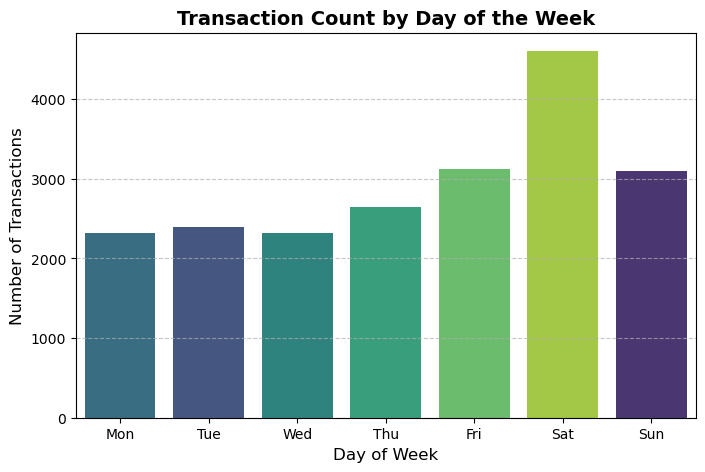

In [ ]:
# Plot Histogram of Transactions by day of week
plt.figure(figsize=(8, 5))
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

sns.countplot(data=discretisized_df, x='temp_day_name', order=day_order, hue='temp_day_name', palette='viridis')
plt.title('Transaction Count by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Clean up temporary column so it doesn't clutter the dataframe
discretisized_df.drop(columns=['temp_day_name'], inplace=True)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
This exploratory analaysis shows that purchasing from bakery peaks significantly on Saturday and even Sunday compared to individual weekdays (Monday through Friday). To simplify rule complexity and mine better and more meaningful rules, we will discritize the this data into Weekend and Weekdays.
</div>

In [ ]:
days_series = pd.to_datetime(discretisized_df['Date']).dt.dayofweek
discretisized_df['Day_Type'] = np.where(days_series >= 5, 'Weekend', 'Weekday')

In [ ]:
discretisized_df.head()

,row_id,Transaction,Date,Time,item_id,item_name,Day_Type
0,1,1,2016-10-30,09:58:11,1,Bread,Weekend
1,2,250,2016-11-01,16:10:42,5,Cookies,Weekday
2,3,159,2016-10-31,14:22:31,1,Bread,Weekday
3,4,79,2016-10-30,14:45:44,6,Muffin,Weekend
4,5,159,2016-10-31,14:22:31,3,Hot chocolate,Weekday


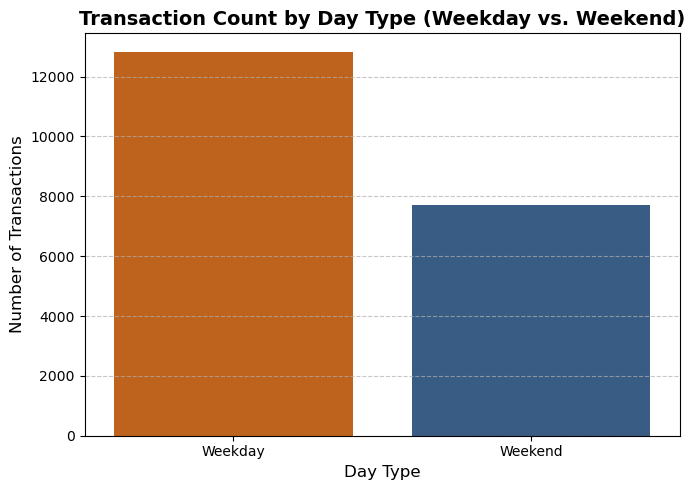

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=discretisized_df,
    x='Day_Type',
    order=['Weekday', 'Weekend'],
    hue='Day_Type',
    palette=['#2b5c8f', '#d95f02'],
    legend=False
)

plt.title('Transaction Count by Day Type (Weekday vs. Weekend)', fontsize=14, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Justification of binning method

For this numerical column the standard statistical binning methods such as equal-width or equal-frequency binning will not be useful because calendar days have fixed numbers rather than continuous numeric distributions. Forcing dates into equal groups would split transactions randomly across weeks or months without making any logical sense. Instead, custom binning was used here to tranform dates into categories of Weekdays and Weekend based on real-world business logic. This makes sense for a bakery because customer habits can largely change between busy workdays and relaxed weekends. As can be seen in the 'Transaction Count by Day Type chart' above, total purchases are higher on weekdays overall (since there are 5 days vs. 2). However, weekends have higher daily customer traffic.

### Discretization of Time

In [ ]:
# Extract hour integer from the Time TEXT

hours_series = discretisized_df['Time'].str.split(':').str[0].astype(int)

time_bins = [-1, 11, 14, 17, 24]
time_labels = ['Morning', 'Noon', 'Afternoon', 'Evening/Night']

# Custom boundary binning using pd.cut
discretisized_df['Time_Period'] = pd.cut(hours_series, bins=time_bins, labels=time_labels)

discretisized_df.head()

,row_id,Transaction,Date,Time,item_id,item_name,Day_Type,Time_Period
0,1,1,2016-10-30,09:58:11,1,Bread,Weekend,Morning
1,2,250,2016-11-01,16:10:42,5,Cookies,Weekday,Afternoon
2,3,159,2016-10-31,14:22:31,1,Bread,Weekday,Noon
3,4,79,2016-10-30,14:45:44,6,Muffin,Weekend,Noon
4,5,159,2016-10-31,14:22:31,3,Hot chocolate,Weekday,Noon


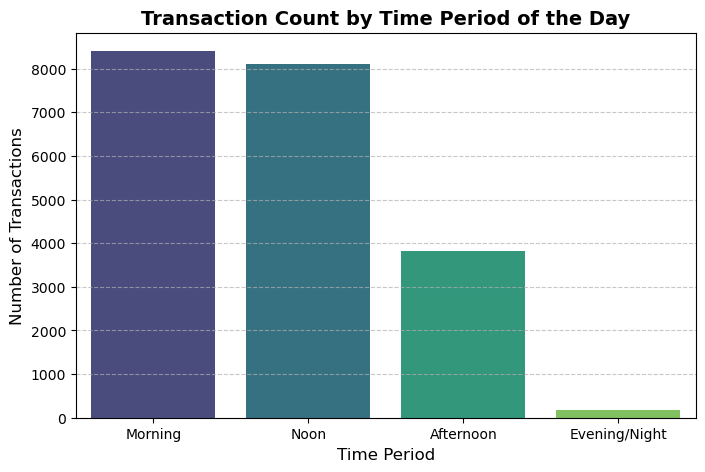

In [ ]:
# Plot Histogram of Transactions by time of the day
plt.figure(figsize=(8, 5))
time_order = ['Morning', 'Noon', 'Afternoon', 'Evening/Night']

sns.countplot(data=discretisized_df, x='Time_Period', order=time_order, hue='Time_Period', palette='viridis')
plt.title('Transaction Count by Time Period of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen from the histogram, the morning and noon periods have the highest number of transactions, dropping sharply during the Afternoon and Evening. This reflects customer buying habits and it might be due to employees and students going to work or school and purchasing breakfast and noon from the bakery during Morning and Noon period.
</div>

#### Justification of binning method

The 'Time' column has exact timestamps like 10:14 AM, which are too detailed for finding general buying habits. In other words, this column has high cardinality which makes it hard for associaiton rule mining algorithms to find recurring patterns. On ther other hand, standard binning techniques like equal-width binning will fail because it would group very different customer behaviours together for instance it could group 6 AM breakfast purchases with 12 PM lunch purchases. That is why for this column we use custom binning based on boundaries and we disretize hours into four categories based on the bakery's operational hours: Morning(less than or equal to 11 AM), Noon (11 AM - 2 PM), Afternoon (2 PM - 5 PM), and Evening/Night (greater than 5 PM).

# Association Rule Mining

##  Show frequency counts for different items

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
A table is created to show frequency counts for all the different itmes in all transactions using a SQL query.
</div>

In [ ]:
# Define SQL Query to get the frequency counts for all items
frequency_query = """
SELECT
    i.item_name,
    COUNT(t.row_id) AS frequency_count
FROM breadbasket_dms t
JOIN items i ON t.item_id = i.item_id
WHERE i.item_name <> 'NONE'     -- we do not want to get the items with name NONE
GROUP BY i.item_name            -- group based on the item name
ORDER BY frequency_count DESC;  -- order in descending order based on the frequency count
"""

# Execute SQL query against database and load the result into a dataframe
item_frequency_df = pd.read_sql(frequency_query, con=engine)

# Display full item frequency table
item_frequency_df.head()

,item_name,frequency_count
0,Coffee,5471
1,Bread,3325
2,Tea,1435
3,Cake,1025
4,Pastry,856


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
This table reveals that Coffee is the most frequent-bought item in the bakery with 5471, followed by Bread and Tea, respectively with 3325 and 1435 counts. Having Cake and Pastry as the next items show that hot beverages and fresh baked goods are the most popular items and the main part of the business.
</div>

In [ ]:
# Number of item types in the dataset
print(f"There are {item_frequency_df.shape[0]} types of items in the dataset")

There are 94 types of items in the dataset


In [ ]:
item_frequency_df.head(-1)

,item_name,frequency_count
0,Coffee,5471
1,Bread,3325
2,Tea,1435
3,Cake,1025
4,Pastry,856
...,...,...
88,Gift voucher,1
89,Adjustment,1
90,Chicken sand,1
91,The BART,1


## Data visualization for the frequency counts for each item.

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
    A suitable visualization for discrete categorical date is a bar chart. A horizontal bar chart would be prefered over a vertical bar chart to accomodate the varying length of text labels without them overlapping, rotating them or truncating them along the x-axis. This is because the dataset contains 94 different types of items, as was demonstrated in the previous section and putting all these items on one chart will make the chart visually very cluttered. Therefore, the chart will highlight the top 'n' most frequent items on the dataset. Especially that these frequent items are the ones that directly impact Association Rule Mining. A second horizontal bar chart was created showing all the items which is hard to read and this shows why top 'n' number were used.
</div>

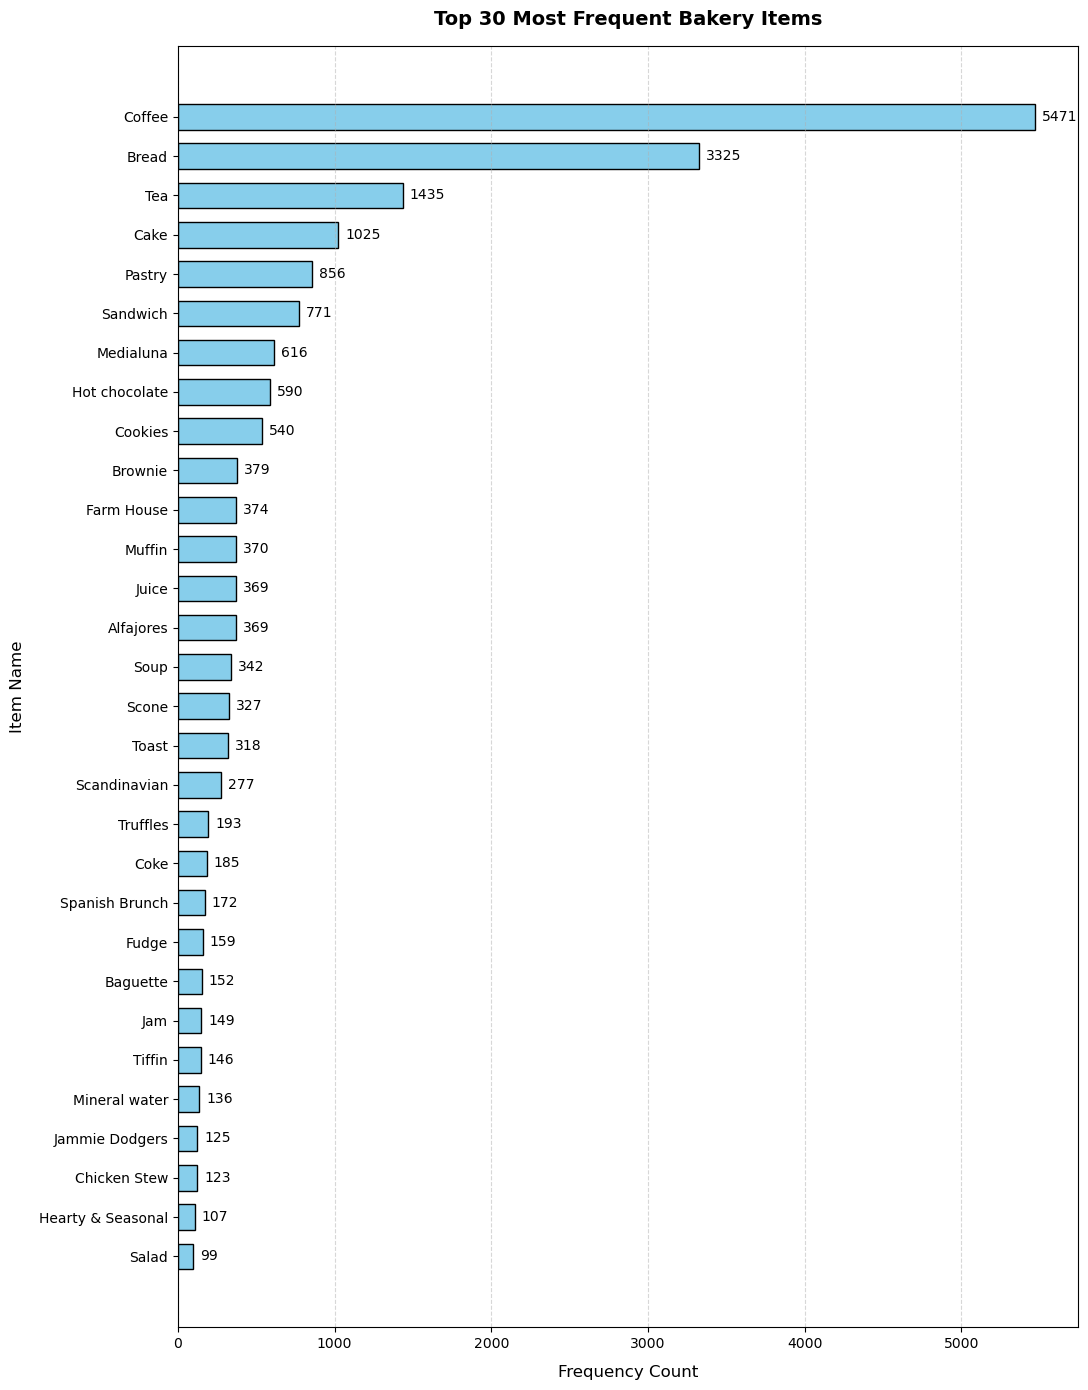

In [ ]:
# Filter for the Top n items (to keep the the chart readable)
top_n = 30
top_items_df = item_frequency_df.head(top_n).sort_values(by='frequency_count', ascending=True)

# Define the categorical data and their corresponding values
categories = top_items_df['item_name']
values = top_items_df['frequency_count']


# Configure the plot size and style
plt.figure(figsize=(11, 14))

# Generate horizontal bar chart
bars = plt.barh(categories, values, color='skyblue', edgecolor='black', height=0.65)


# Defining the chart title and labels
plt.title('Top 30 Most Frequent Bakery Items', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency Count', fontsize=12, labelpad=10)
plt.ylabel('Item Name', fontsize=12, labelpad=10)

# Put the exact numerical value labels directly on top of each bar
plt.bar_label(bars, padding=5, fontsize=10)

# Add subtle grid lines for readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Optimize layout spacing and demonstrate the bar chart
plt.tight_layout()
plt.show()

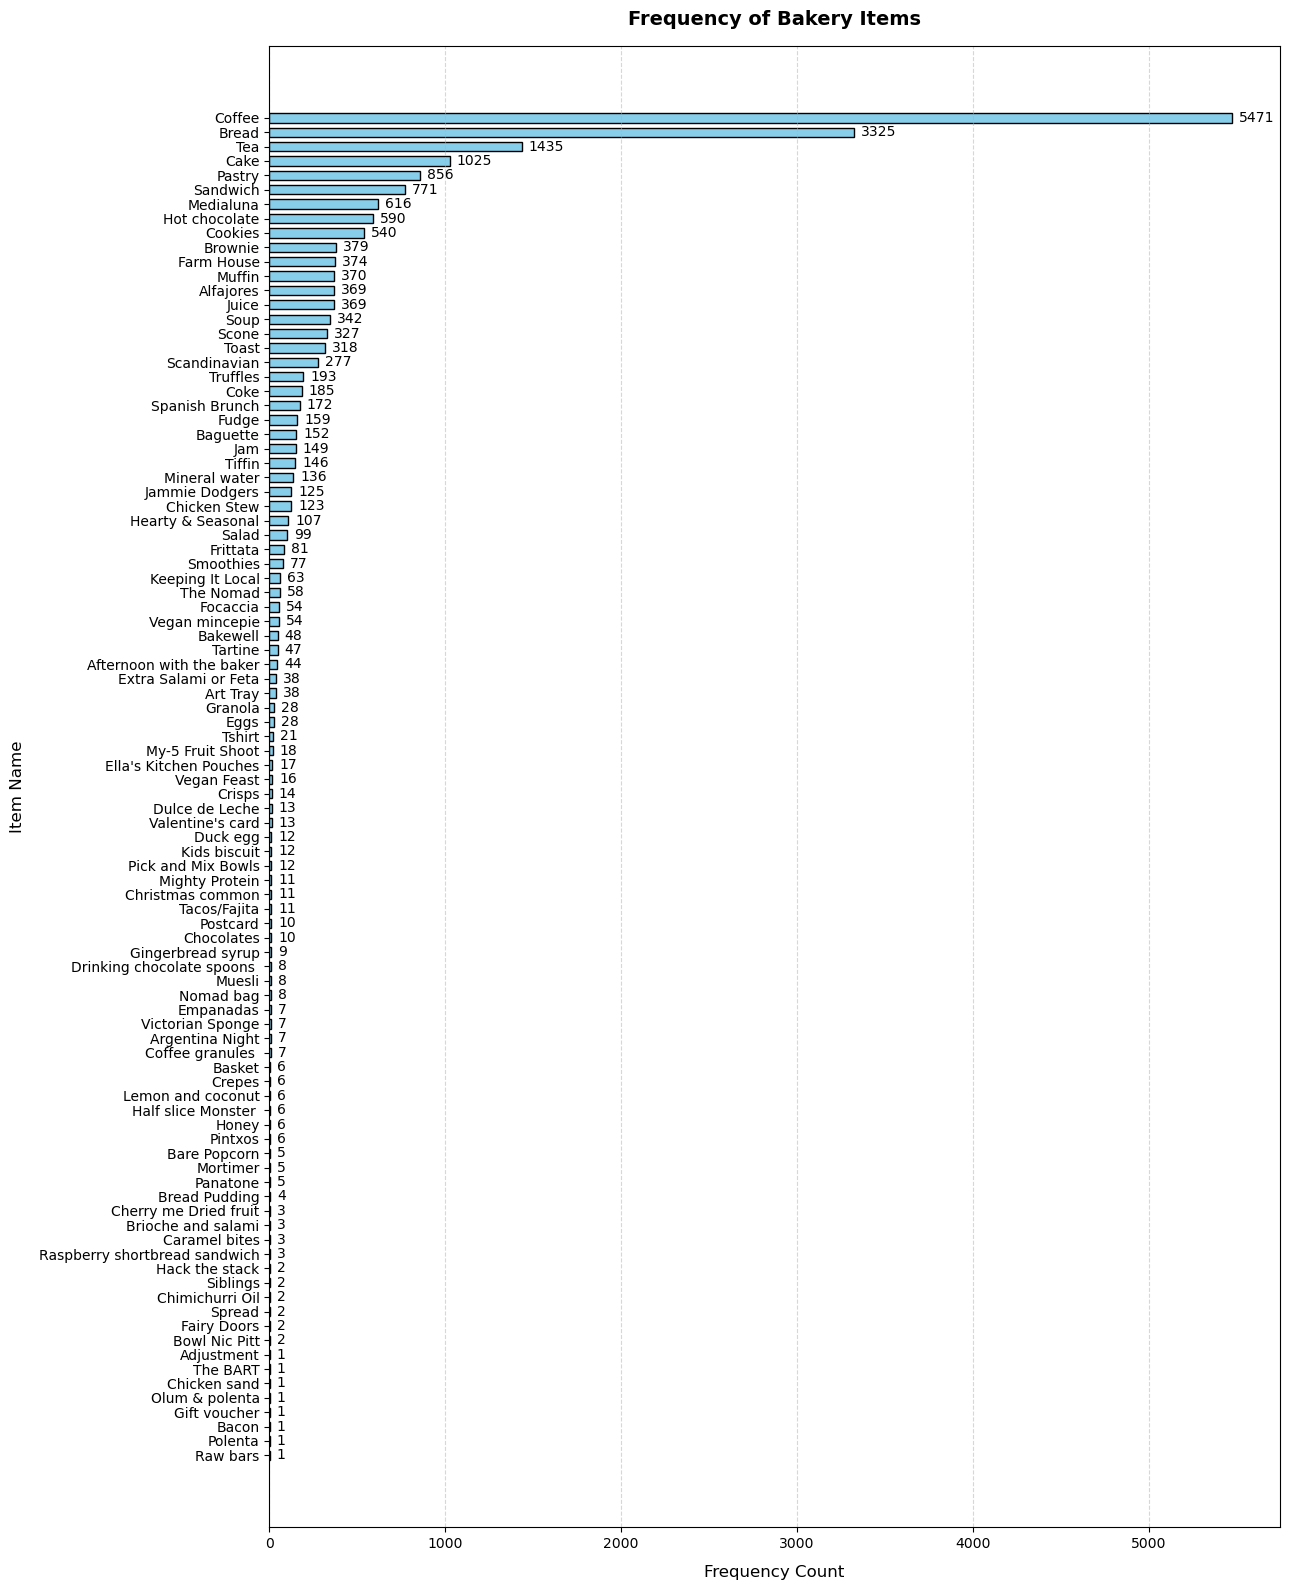

In [ ]:
# Order the categories
ordered_items_df = item_frequency_df.sort_values(by='frequency_count', ascending=True)

# Define the categorical data and their corresponding values
categories = ordered_items_df['item_name']
values = ordered_items_df['frequency_count']

# Configure the plot size and style
plt.figure(figsize=(13, 16))

# Generate horizontal bar chart
bars = plt.barh(categories, values, color='skyblue', edgecolor='black', height=0.65)


# Defining the chart title and labels
plt.title('Frequency of Bakery Items', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency Count', fontsize=12, labelpad=10)
plt.ylabel('Item Name', fontsize=12, labelpad=10)

# Put the exact numerical value labels directly on top of each bar
plt.bar_label(bars, padding=5, fontsize=10)

# Add subtle grid lines for readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Optimize layout spacing and demonstrate the bar chart
plt.tight_layout()
plt.show()

## Create association rules

### Convert One-hot encoding

In [ ]:
discretisized_df.head(-1)

,row_id,Transaction,Date,Time,item_id,item_name,Day_Type,Time_Period
0,1,1,2016-10-30,09:58:11,1,Bread,Weekend,Morning
1,2,250,2016-11-01,16:10:42,5,Cookies,Weekday,Afternoon
2,3,159,2016-10-31,14:22:31,1,Bread,Weekday,Noon
3,4,79,2016-10-30,14:45:44,6,Muffin,Weekend,Noon
4,5,159,2016-10-31,14:22:31,3,Hot chocolate,Weekday,Noon
...,...,...,...,...,...,...,...,...
21287,21288,9682,2017-04-09,14:32:58,95,Tacos/Fajita,Weekend,Noon
21288,21289,9682,2017-04-09,14:32:58,7,Coffee,Weekend,Noon
21289,21290,9682,2017-04-09,14:32:58,10,Tea,Weekend,Noon
21290,21291,9683,2017-04-09,14:57:06,7,Coffee,Weekend,Noon


In [ ]:
# Group by Transaction and collect all features into a single basket
basket_df = discretisized_df.groupby('Transaction').apply(
    lambda x: list(set(
        x['item_name'].tolist() +
        [x['Time_Period'].iloc[0]] +
        [x['Day_Type'].iloc[0]]
    )),
    include_groups=False
)

# Convert to list of lists for TransactionEncoder
transactions = basket_df.tolist()

In [ ]:
# Initialize TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert boolean array into a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Transaction Table:\n")
print(df_encoded)

Transaction Table:

      Adjustment  Afternoon  Afternoon with the baker  Alfajores  \
0          False      False                     False      False   
1          False      False                     False      False   
2          False      False                     False      False   
3          False      False                     False      False   
4          False      False                     False      False   
...          ...        ...                       ...        ...   
9460       False      False                     False      False   
9461       False      False                     False      False   
9462       False      False                     False      False   
9463       False      False                     False      False   
9464       False       True                     False      False   

      Argentina Night  Art Tray  Bacon  Baguette  Bakewell  Bare Popcorn  \
0               False     False  False     False     False         False   
1          

In [ ]:
# Run Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.00105, use_colnames=True)

# Generate Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.20)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
To prepare the dataset for association rule mining, individual rows are grouped by Transaction ID to create a single "basket" of items for each purchase. This basket combines the purchased bakery items along with their corresponding discretized time period and day type. Since algorithms like Apriori require a binary matrix input, 'TransactionEncoder' is used to convert the transaction lists into a one-hot encoded (boolean) format.
</div>

### Calculate Support Threshold

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Note: Looking at the highest Transaction ID we can see that there are 9465 unique transactions in this dataset. However, previously when printing out the dataset dataframe, we saw that the highest transaction was 9,684. This is because some numbers were skipped as a transaction ID, such as the number 53, and some rows were also dropped because of having item_name as NONE.
</div>

In [ ]:
total_transactions = len(df_encoded)
min_support_value = 10 / total_transactions

print(f"\nTotal Unique Transactions: {total_transactions}")
print(f"Calculated min_support threshold (10 transactions): {min_support_value:.6f}\n")


Total Unique Transactions: 9465
Calculated min_support threshold (10 transactions): 0.001057



### Run Apriori Algorithm

In [ ]:
start = time.perf_counter()

# Extracting frequent itemsets with
frequent_apriori = apriori(
    df_encoded,
    min_support=min_support_value,
    use_colnames=True
)

# Generate association rules
rules_apriori = association_rules(
    frequent_apriori,
    metric="confidence",
    min_threshold=0.1
)

end = time.perf_counter()
apriori_time = end - start

print(f"Apriori Time: {apriori_time:.6f} seconds")
print(f"Frequent Itemsets Found: {len(frequent_apriori)}")
print(f"Association Rules Generated: {len(rules_apriori)}\n")

Apriori Time: 0.533333 seconds
Frequent Itemsets Found: 2147
Association Rules Generated: 6476



In [ ]:
# Format Frequent Itemsets
display_itemsets = frequent_apriori.copy()
display_itemsets['itemsets'] = display_itemsets['itemsets'].apply(format_frozenset)

print("Frequent Itemsets (Sample):")
print(display_itemsets.head(10))


Frequent Itemsets (Sample):
    support                  itemsets
0  0.175489                 Afternoon
1  0.004543  Afternoon with the baker
2  0.036344                 Alfajores
3  0.004015                  Art Tray
4  0.016059                  Baguette
5  0.005071                  Bakewell
6  0.327205                     Bread
7  0.040042                   Brownie
8  0.103856                      Cake
9  0.012995              Chicken Stew


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Using the calculated minimum support threshold (min_support) 0.001057, the standard Apriori algorithm mined a total of 2,147 frequent itemsets across the dataset in approximately 0.57 seconds.

From these frequent itemsets, 6,476 raw association rules were initially generated using a broad confidence baseline of 10% (min_threshold = 0.10). As can be seen in the frequent itemsets sample, individual single-item support values vary significantly ranging from tags like 'Afternoon' (17.5%) and bakery items like 'Bread' (32.7%) to less frequent items like 'Chicken Stew' (1.3%).
</div>

## Improving the efficiency of the Apriori algorithm using vertical data format approach

In [ ]:
# Reference: https://www.geeksforgeeks.org/machine-learning/ml-eclat-algorithm/

In [ ]:
# Create a unified list of all items, time tags, and day tags per transaction
vertical_df = discretisized_df.melt(
    id_vars=['Transaction'],
    value_vars=['item_name', 'Time_Period', 'Day_Type'],
    value_name='item'
)[['Transaction', 'item']].drop_duplicates()

vertical_db = vertical_df.groupby('item')['Transaction'].apply(set).to_dict()

In [ ]:
total_transactions = discretisized_df['Transaction'].nunique()
min_support_count = 10
min_support_fraction = min_support_count / total_transactions

print(f"\nTotal Unique Transactions: {total_transactions}")
print(f"Calculated min_support threshold (10 transactions): {min_support_fraction:.6f}\n")


Total Unique Transactions: 9465
Calculated min_support threshold (10 transactions): 0.001057



In [ ]:
# Vertical Mining Algorithm using (ECLAT -Equivalence Class Clustering and bottom-up Lattice Traversal)
start = time.perf_counter()

frequent_itemsets_dict = {}

# Filter items meeting absolute support threshold
L1 = {frozenset([item]): tids for item, tids in vertical_db.items() if len(tids) >= min_support_count}
frequent_itemsets_dict.update(L1)

# Recursive Depth-First Search
def eclat(current_itemsets, k):
    items = list(current_itemsets.keys())
    next_level = {}

    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            itemset1, tids1 = items[i], current_itemsets[items[i]]
            itemset2, tids2 = items[j], current_itemsets[items[j]]

            # Combine itemsets if they share a prefix
            union_set = itemset1 | itemset2
            if len(union_set) == k:
                if union_set not in frequent_itemsets_dict:
                    # Set intersection of transaction IDs
                    intersection_tids = tids1 & tids2
                    if len(intersection_tids) >= min_support_count:
                        next_level[union_set] = intersection_tids
                        frequent_itemsets_dict[union_set] = intersection_tids

    if next_level:
        eclat(next_level, k + 1)
# Execute ECLAT search starting at k=2
eclat(L1, k=2)

# Convert results into standard DataFrame format
frequent_vertical_df = pd.DataFrame([
    {'itemsets': itemset, 'support': len(tids) / total_transactions}
    for itemset, tids in frequent_itemsets_dict.items()
])

end = time.perf_counter()
vertical_time = end - start

print("--- VERTICAL DATA FORMAT RESULTS ---")
print(f"Vertical Mining Execution Time: {vertical_time:.6f} seconds")
print(f"Frequent Itemsets Found: {len(frequent_vertical_df)}")


--- VERTICAL DATA FORMAT RESULTS ---
Vertical Mining Execution Time: 0.409715 seconds
Frequent Itemsets Found: 2147


In [ ]:
print("--- COMPARISON SUMMARY ---")
print(f"Standard Apriori Time: {apriori_time:.6f} seconds")
print(f"Vertical Format Time:  {vertical_time:.6f} seconds")
print(f"Speedup Factor:        {apriori_time / vertical_time:.2f}x faster")
print(f"\nItemsets Match? {len(frequent_apriori) == len(frequent_vertical_df)}")
print(f"Rules Match?    {len(rules_apriori) == len(rules_vertical)}")

--- COMPARISON SUMMARY ---
Standard Apriori Time: 0.533333 seconds
Vertical Format Time:  0.409715 seconds
Speedup Factor:        1.30x faster

Itemsets Match? True
Rules Match?    False


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Vertical Data Format approach improves the efficiency of the Apriori algorithm by reducing database scans and imrpoving support count calculation through fast set intersection operations. The apriori algorithm maps a transaction ID to a list of contained items and iteratively scans the entire dataset for every level in order to find the frequent itemsets. However, the veritical approach, maps every individual item to a list of transaction IDs that hold that item and operates on these lists. This also bypasses the memory overhead of one-hot encoded matrix that the Apriori algorithm needs.
    From the results of running both algorithms we can see that the second approach, the vertical data format using eclat is more efficient as it was able to find the same number of frequent itemsets (2147 items) in 0.409715 seconds which is 1.30x faster than the Apriori algorithm which took 0.533333 seconds to run. However, we can see that the rules found by this algorithm does not match the apriori algorithm's rules identified which is expected since the veritical data format approach generates a subset of the rules due to its underlying algorithm.

</div>

## Sort the rules

In [ ]:
# Define sets of the time and day tags
TIME_TAGS = {'Morning', 'Noon', 'Afternoon', 'Evening/Night'}
DAY_TAGS = {'Weekday', 'Weekend'}

# Helper functions that return True/False for each rule
def is_product_only(row):
    # Combines antecedents and consequents sets
    items = row['antecedents'].union(row['consequents'])
    # Returns True if NONE of the items are in TIME_TAGS or DAY_TAGS
    return items.isdisjoint(TIME_TAGS) and items.isdisjoint(DAY_TAGS)

def is_time_rule(row):
    items = row['antecedents'].union(row['consequents'])
    # Has at least one time tag, but no day tags
    has_time = not items.isdisjoint(TIME_TAGS)
    has_day = not items.isdisjoint(DAY_TAGS)
    return has_time and not has_day

def is_day_rule(row):
    items = row['antecedents'].union(row['consequents'])
    # Has at least one day tag, but no time tags
    has_time = not items.isdisjoint(TIME_TAGS)
    has_day = not items.isdisjoint(DAY_TAGS)
    return has_day and not has_time

categories = {
"Product-to-Product Rules": rules_apriori[rules_apriori.apply(is_product_only, axis=1)],
"Product-to-Time Rules":    rules_apriori[rules_apriori.apply(is_time_rule, axis=1)],
"Product-to-Day Rules":     rules_apriori[rules_apriori.apply(is_day_rule, axis=1)]
}


### Top rules sorted by Support

In [ ]:
print("*" * 80)
print("TOP RULES SORTED BY SUPPORT")
print("*" * 80)

for name, df in categories.items():
    display_df = df.copy()
    display_df['antecedents'] = display_df['antecedents'].apply(format_frozenset_brackets)
    display_df['consequents'] = display_df['consequents'].apply(format_frozenset_brackets)

    print(f"\n--- {name} (Top 10 by SUPPORT) ---")
    sorted_df = display_df.sort_values(by='support', ascending=False)
    display(sorted_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

********************************************************************************
TOP RULES SORTED BY SUPPORT
********************************************************************************

--- Product-to-Product Rules (Top 10 by SUPPORT) ---


,antecedents,consequents,support,confidence,lift
75,{Coffee},{Bread},0.090016,0.188163,0.575059
74,{Bread},{Coffee},0.090016,0.275105,0.575059
124,{Coffee},{Cake},0.054728,0.114399,1.101515
123,{Cake},{Coffee},0.054728,0.526958,1.101515
186,{Tea},{Coffee},0.049868,0.349630,0.730840
185,{Coffee},{Tea},0.049868,0.104240,0.730840
176,{Pastry},{Coffee},0.047544,0.552147,1.154168
178,{Sandwich},{Coffee},0.038246,0.532353,1.112792
169,{Medialuna},{Coffee},0.035182,0.569231,1.189878
164,{Hot chocolate},{Coffee},0.029583,0.507246,1.060311



--- Product-to-Time Rules (Top 10 by SUPPORT) ---


,antecedents,consequents,support,confidence,lift
171,{Morning},{Coffee},0.223244,0.514989,1.076495
172,{Coffee},{Morning},0.223244,0.466652,1.076495
174,{Noon},{Coffee},0.173270,0.457079,0.955445
175,{Coffee},{Noon},0.173270,0.362191,0.955445
92,{Bread},{Morning},0.157422,0.481111,1.109850
91,{Morning},{Bread},0.157422,0.363149,1.109850
94,{Noon},{Bread},0.116006,0.306020,0.935253
95,{Bread},{Noon},0.116006,0.354537,0.935253
9,{Coffee},{Afternoon},0.079979,0.167182,0.952666
10,{Afternoon},{Coffee},0.079979,0.455750,0.952666



--- Product-to-Day Rules (Top 10 by SUPPORT) ---


,antecedents,consequents,support,confidence,lift
193,{Coffee},{Weekday},0.315267,0.659011,1.015059
192,{Weekday},{Coffee},0.315267,0.485598,1.015059
110,{Weekday},{Bread},0.206339,0.317819,0.971314
111,{Bread},{Weekday},0.206339,0.630610,0.971314
194,{Weekend},{Coffee},0.163127,0.465060,0.972128
195,{Coffee},{Weekend},0.163127,0.340989,0.972128
113,{Bread},{Weekend},0.120866,0.369390,1.053095
112,{Weekend},{Bread},0.120866,0.344578,1.053095
385,{Tea},{Weekday},0.096989,0.680000,1.047388
384,{Weekday},{Tea},0.096989,0.149390,1.047388


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their support value which represent how many times the itemset appeared together in the dataset. The formula for this metric is: support = (number of transactions containing the itemset) / Total number of transactions. The highest product-to-product itemset in the table is {Bread} → {Coffee}, which has a support of 0.090016, and since we have 9,465 number of unique transactions, therefore, based on the given formula we have -> 0.090016 x 9465 ≈ 852. This means that bread and coffee were bought together in about 858 separate transactions.<br>
    <br>Similarly, the product-to-time rules were also sorted by their support values, which highlights the transaction volume for items during specific times of the day. The highest-ranking rule here is {Morning} → {Coffee} (or {Coffee} → {Morning}), which has a support of 0.223244. If we apply the formula we will get: 0.223244 x 9,465 ≈ 2,113. This means that over 2,128 transactions involved a coffee purchase during the morning hours. Next in the table are {Noon} → {Coffee} (1,651 transactions) and {Morning} → {Bread} (1,500 transactions). Ths shows that morning coffee and bread, alongside lunch coffee are the backbone of overall customer demand.<br>
     <br>Lastly, we have the product-to-day rules sorted by support, which measures how items sales are distributed across different day types (weekdays vs weekend). The top rule is {Coffee} → {Weekday} and has a support of 0.315267. If we apply the formula we have: 0.315267 x 9,465 ≈ 2.99. This shows that over 3,000 transacctions are related to coffee sales during the weekdays. Meanwhile in the sixth place we have {Coffee} → {Weekend}, which accounts for about 1,555 transactions (0.163127 x 9,465). While individual weekend days have higher daily operations (based on what we saw earlier when discretizing as well), weekdays generally have higher transactions when added together as they span over five operational days rather than two (Saturday & Sunday).

</div>

### Top rules sorted by Confidence

In [ ]:
print("*" * 80)
print("TOP RULES SORTED BY CONFIDENCE")
print("*" * 80)

for name, df in categories.items():
    display_df = df.copy()
    display_df['antecedents'] = display_df['antecedents'].apply(format_frozenset_brackets)
    display_df['consequents'] = display_df['consequents'].apply(format_frozenset_brackets)

    print(f"\n--- {name} (Top 10 by CONFIDENCE) ---")
    sorted_df = display_df.sort_values(by='confidence', ascending=False)
    display(sorted_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

********************************************************************************
TOP RULES SORTED BY CONFIDENCE
********************************************************************************

--- Product-to-Product Rules (Top 10 by CONFIDENCE) ---


,antecedents,consequents,support,confidence,lift
1641,"{Extra Salami or Feta, Salad}",{Coffee},0.001479,0.875000,1.829036
1946,"{Pastry, Toast}",{Coffee},0.001373,0.866667,1.811617
1693,"{Hearty & Seasonal, Sandwich}",{Coffee},0.001268,0.857143,1.791709
1397,"{Cake, Vegan mincepie}",{Coffee},0.001057,0.833333,1.741939
1955,"{Salad, Sandwich}",{Coffee},0.001585,0.833333,1.741939
158,{Extra Salami or Feta},{Coffee},0.003275,0.815789,1.705267
168,{Keeping It Local},{Coffee},0.005388,0.809524,1.692169
1620,"{Cookies, Scone}",{Coffee},0.001585,0.789474,1.650258
1757,"{Juice, Pastry}",{Coffee},0.001796,0.772727,1.615253
1374,"{Cake, Salad}",{Coffee},0.001057,0.769231,1.607944



--- Product-to-Time Rules (Top 10 by CONFIDENCE) ---


,antecedents,consequents,support,confidence,lift
2234,"{Hearty & Seasonal, Sandwich}",{Noon},0.001479,1.000000,2.637960
2600,"{Salad, Spanish Brunch}",{Noon},0.001268,1.000000,2.637960
4092,"{Bread, Sandwich, Soup}",{Noon},0.001057,1.000000,2.637960
2360,"{Juice, Salad}",{Noon},0.001057,1.000000,2.637960
217,{Postcard},{Evening/Night},0.001057,1.000000,83.761062
4588,"{Coffee, Coke, Sandwich}",{Noon},0.002007,1.000000,2.637960
4729,"{Coffee, Farm House, Pastry}",{Morning},0.001057,1.000000,2.306849
4763,"{Coffee, Hearty & Seasonal, Sandwich}",{Noon},0.001268,1.000000,2.637960
219,{Tshirt},{Evening/Night},0.002219,1.000000,83.761062
2594,"{Salad, Sandwich}",{Noon},0.001796,0.944444,2.491407



--- Product-to-Day Rules (Top 10 by CONFIDENCE) ---


,antecedents,consequents,support,confidence,lift
396,{Tshirt},{Weekend},0.002219,1.000000,2.850904
2579,"{Muffin, Soup}",{Weekday},0.001268,1.000000,1.540277
349,{Postcard},{Weekend},0.001057,1.000000,2.850904
377,{Tacos/Fajita},{Weekend},0.001162,1.000000,2.850904
2444,"{Medialuna, Scone}",{Weekend},0.001373,0.928571,2.647268
767,"{Alfajores, Mineral water}",{Weekday},0.001162,0.916667,1.411920
2252,"{Hearty & Seasonal, Soup}",{Weekday},0.001162,0.916667,1.411920
3897,"{Bread, Hot chocolate, Scone}",{Weekend},0.001057,0.909091,2.591731
4951,"{Juice, Toast, Weekend}",{Coffee},0.001057,0.909091,1.900297
1783,"{Keeping It Local, Weekend}",{Coffee},0.001585,0.882353,1.844406


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their confidence value, which represents how often the consequent is purchased when the antecedent is purchased. The formula for this metric is: Confidence = Support(antecedent -> consequent)/Support (antecedent). <br>
    <br>The highest rule in the product-to-product table is {Extra Salami or Feta, Salad} → {Coffee}, with a confidence of 0.875. This means that 87.5% of transactions that contained both Extra Salami or Feta and Salad also included Coffee. In other words, this rule predicts the purchase of Coffee in about 88 out of every 100 transactions that contains the antecedent. <br>
     <br>In the product-to-time category, confidence measures the likelihood that a specific item combination is purchased within a particular operating time period. As can be seen from the table, multiple rules have a perfect confidence score of 1.00 (100%), such as {Coffee, Hearty & Seasonal, Sandwich} → {Lunch/Noon} and {Salad, Spanish Brunch} → {Noon}. This means that 100% of transactions containing those item sets happened during the Noon period. <br>
    <br>Lastly, sorting product-to-day rules by confidence shows a strong day-type purchasing behvaiour. Top rules like {Tshirt} → {Weekend}, {Tacos/Fajita} → {Weekend}, and {Muffin, Soup} → {Weekday} demonstrate a confidence of 1.00 (100%) which shows that certain items are purchased on either weekends or weekdays 100% of the time. This highlights that there can be a day-specific marketing or inventory stocking opportunity for the bakery.
</div>

### Top rules sorted by Lift

In [ ]:
print("*" * 80)
print("TOP RULES SORTED BY LIFT")
print("*" * 80)

for name, df in categories.items():
    display_df = df.copy()
    display_df['antecedents'] = display_df['antecedents'].apply(format_frozenset_brackets)
    display_df['consequents'] = display_df['consequents'].apply(format_frozenset_brackets)

    print(f"\n--- {name} (Top 10 by LIFT) ---")
    sorted_df = display_df.sort_values(by='lift', ascending=False)
    display(sorted_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

********************************************************************************
TOP RULES SORTED BY LIFT
********************************************************************************

--- Product-to-Product Rules (Top 10 by LIFT) ---


,antecedents,consequents,support,confidence,lift
1643,{Extra Salami or Feta},"{Coffee, Salad}",0.001479,0.368421,56.243633
1639,"{Coffee, Salad}",{Extra Salami or Feta},0.001479,0.225806,56.243633
1642,{Salad},"{Coffee, Extra Salami or Feta}",0.001479,0.141414,43.176931
1640,"{Coffee, Extra Salami or Feta}",{Salad},0.001479,0.451613,43.176931
224,{Salad},{Extra Salami or Feta},0.001690,0.161616,40.255183
225,{Extra Salami or Feta},{Salad},0.001690,0.421053,40.255183
750,"{Alfajores, Cookies}",{Juice},0.001057,0.434783,11.274568
241,{Fudge},{Jam},0.002536,0.169014,11.265622
240,{Jam},{Fudge},0.002536,0.169014,11.265622
2061,"{Juice, Sandwich}",{Coke},0.001057,0.181818,9.352767



--- Product-to-Time Rules (Top 10 by LIFT) ---


,antecedents,consequents,support,confidence,lift
217,{Postcard},{Evening/Night},0.001057,1.000000,83.761062
219,{Tshirt},{Evening/Night},0.002219,1.000000,83.761062
218,{Evening/Night},{Tshirt},0.002219,0.185841,83.761062
4709,"{Extra Salami or Feta, Noon}","{Coffee, Salad}",0.001268,0.480000,73.277419
4710,"{Coffee, Salad}","{Extra Salami or Feta, Noon}",0.001268,0.193548,73.277419
4705,"{Coffee, Extra Salami or Feta, Noon}",{Salad},0.001268,0.631579,60.382775
4713,{Salad},"{Coffee, Extra Salami or Feta, Noon}",0.001268,0.121212,60.382775
4704,"{Coffee, Noon, Salad}",{Extra Salami or Feta},0.001268,0.235294,58.606811
4714,{Extra Salami or Feta},"{Coffee, Noon, Salad}",0.001268,0.315789,58.606811
2158,"{Extra Salami or Feta, Noon}",{Salad},0.001479,0.560000,53.539394



--- Product-to-Day Rules (Top 10 by LIFT) ---


,antecedents,consequents,support,confidence,lift
2217,"{Fudge, Weekend}",{Jam},0.001162,0.183333,12.220070
2216,"{Jam, Weekend}",{Fudge},0.001162,0.177419,11.825875
2213,"{Jam, Weekday}",{Fudge},0.001373,0.162500,10.831426
2214,"{Fudge, Weekday}",{Jam},0.001373,0.158537,10.567245
4941,"{Coffee, Juice, Weekend}",{Spanish Brunch},0.001479,0.175000,9.630087
4944,"{Juice, Weekend}","{Coffee, Spanish Brunch}",0.001479,0.101449,9.322499
4946,"{Coffee, Spanish Brunch}","{Juice, Weekend}",0.001479,0.135922,9.322499
2390,"{Juice, Weekend}",{Spanish Brunch},0.001796,0.123188,6.778943
4943,"{Spanish Brunch, Weekend}","{Coffee, Juice}",0.001479,0.138614,6.728104
2736,{Smoothies},"{Sandwich, Weekend}",0.001162,0.142857,6.231073


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their lift value, which measures how much more likely the antecedent and consequent are to happen together compared to a random chance. The formula for lift is: Life = Confidence (anticedent -> consequent) / Support(consequent). The highest rule in the produt-to-product table is {Extra Salami or Feta} → {Coffee, Salad}, which has a lift of 56.24. This means that customers who buy Extra Salami or Feta are about 56 times more likely to also buy Coffee and Salad together than would be expected if these items were bought independently. Althoug this rule has a low support where it occures on only a small number of transactions (0.001479 x 9,465 ≈ 14), its high lift indicates a strong association between these items.<br>
    <br>Sorting product-to-time rules by lift isolates special items that are purchased during special time of the day. Rules that have a murchandise like {Tshirt} → {Evening/Night} and {Postcard} → {Evening/Night} reach a lift of 83.761062, which shows that non-food merchandise purchases are mainly purchased during evening operating hours. Additioanlly, rules that have lunch items such as such as {Extra Salami or Feta, Noon} → {Coffee, Salad} (Lift = 73.277419) demonstrate that meal purchases occur at rates that are higher during lunch across general baseline operating hours.<br>
    <br>Lastly, the sorting of the product-to-day category by lift shows item pairings that their co-occurence is heavilily increased by the day of the week For instance, {Fudge, Weekend} → {Jam} (Lift = 12.220070) and {Jam, Weekend} → {Fudge} (Lift = 11.825875) demonstrate that while Jam and Fudge are strongly associated overall, their joint purchase likelihood increases even further during the weekend.  
</div>

## Selection of thresholds

### Support Threshold

Support means how many times the an item shows up on the whole dataset, in other words the frequency of an itemset across the entire dataset. Choosing a support threshold that is too low would keep many of the rare item combinations that might have happened by chance. On the other hand, choosing a support threshold that is too hight removes even the combinations that will help in identifying useful buying patterns.

Our bakery dataset contains 9,465 unique transactions. As seen in the'Top Rules Sorted by Support table' for the product-to-product category, the most frequent item combination in the entire bakery, {Bread} -> {Coffee}, has a support of 0.090016(≈9%). This shows that even the most common product pair appears in less than one out of every ten transactions. For product-to-item and product-to-day categories the support values are naturally higher (e.g., {Coffee} → {Weekday} at ≈ 31.5% and {Morning} → {Coffee} at ≈ 22.3%) as they aggregate thousands of sales during their time window.

If we choose a support threshold of $0.001$ (0.1%) it would mean that an itemset must appear in at least 9.5 (0.001×9465≈9.5) or about 10 transaction before it is considered frequent. Using a much larger support threshold (like 5%) would remove many meaningful purchasing patterns but 0.1% threshold ensures that an item pair must appear together in at least 10 separate purchases and if they appear less than 10 times, then they should not affect how the store changes its sales strategies. Selecting 0.1% 0 reduces the effect of accidental or very rare purchases while keeping meaningful buying patterns.

### Confidence Threshold

In [ ]:
print(display_df["confidence"].describe())

count    1368.000000
mean        0.373087
std         0.211975
min         0.100000
25%         0.174901
50%         0.341226
75%         0.545455
max         1.000000
Name: confidence, dtype: float64


Confidense measures how often the consequent is purchased when the antecedent is purchased. For instance if we have a confidence of 0.80, it means that 80% of customers who bought the first item, also bought the second item. As can be seen in the 'Top Rules Sorted by Confidence' for the product-to-product table above, the top 10 highest confidence values in the dataset range from about 0.77 to 0.88 and this shows that some item combinations are very reliable. For the other two categories we can see high numbers ranging from 0.88 to 1.00, which demonstrates highly reliable purchasing.

To find a confidence threshold, the confidence distribution was evaluated using descriptve statistics which showed a median of 0.3412 (34.1%), and an interquartile rage from 17.5% (25th percentile) to 54.5% (75th percentile). The confidence threshold chosen is $0.20$ because it is above the 25th percentile (17.5%) while being below the median (34.1%) which keeps many meaningful purchasing patterns while filtering out very weak rules.

The reason a higher threshold was not chosen is that it would severely restrct rule discovery. If we put the threshold to 30% or 50% for instance, important rules for discovering such as {Bread} → {Coffee} which has a support of 0.009 and a confidence of 27.5% or {Tea} → {Coffee} which has a support of 0.049868 and a confidence of 35% will get discarded. Conversely, if we put the threshold below 10%, it will allow weak relationships that are based on coincidence to be included.A rule with 0.05 (5%) confidence would mean that 95% of the time the prediction failes and this offers no actionable value for the store.

Since confidence does not consider how common the items are, it is used together with support and lift to ensure that the selected rules are reliable and meaningful.

### Lift Threshold

Lift measures how much more likely two items are to be purchased together cimpared with random chance. Unlike confidence, lift takes into account how common the consequent is.This prevents very popular items such as coffee from having strong associations just because they are purchased frequently. A lift value of 1 means the items co-occur by random chance and are independent. A lift value less than 1 means they occur together less often than expected, and a lift value greater than 1 means they have a positive association.

As can be seen in the 'Top Rules Sorted by Support' table above for product-to-product, some common rules such as {Bread} -> {Coffee} have a lift of about 0.575, which is less than 1 and reveals that although Bread and Coffee are both popular individually, buying Bread actually decreases the likelihood of buying Coffee compared to average customer expectations.

To filter out these independent or negatively correlated rules, the lift threshold is selected to be $1.2$. This helps ensure that any identified rule represents a co-occurrence rate at least 20% higher than random chance and isolates geniune rules such as {Fudge} → {Jam} at Lift = 11.27.

#### Identify Interesting Rules

In [ ]:
# Applying the selected thresholds to identify interesting rules
interesting_rules_raw = rules_apriori[
    (rules_apriori['support'] >= 0.001) &
    (rules_apriori['confidence'] >= 0.20) &
    (rules_apriori['lift'] >= 1.20)].copy()


interesting_categories = {
    "Product-to-Product Rules": interesting_rules_raw[interesting_rules_raw.apply(is_product_only, axis=1)],
    "Product-to-Time Rules":    interesting_rules_raw[interesting_rules_raw.apply(is_time_rule, axis=1)],
    "Product-to-Day Rules":     interesting_rules_raw[interesting_rules_raw.apply(is_day_rule, axis=1)]
}

print(f"Total Rules Originally Found: {len(rules_apriori)}")
print(f"Total 'Interesting' Rules Remaining: {len(interesting_rules_raw)}\n")

# Format into brackets & Display Top 10 for Each Category (Sorted by lift)
for name, df in interesting_categories.items():
    print(f" INTERESTING {name.upper()} (Total: {len(df)})")

    # Format frozenset brackets for display
    display_df = df.copy()
    display_df['antecedents'] = display_df['antecedents'].apply(format_frozenset_brackets)
    display_df['consequents'] = display_df['consequents'].apply(format_frozenset_brackets)

    # Sort by Lift descending to highlight the top actionable associations
    top_df = display_df.sort_values(by='lift', ascending=False)
    display(top_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Total Rules Originally Found: 6476
Total 'Interesting' Rules Remaining: 2078

 INTERESTING PRODUCT-TO-PRODUCT RULES (Total: 124)


,antecedents,consequents,support,confidence,lift
1643,{Extra Salami or Feta},"{Coffee, Salad}",0.001479,0.368421,56.243633
1639,"{Coffee, Salad}",{Extra Salami or Feta},0.001479,0.225806,56.243633
1640,"{Coffee, Extra Salami or Feta}",{Salad},0.001479,0.451613,43.176931
225,{Extra Salami or Feta},{Salad},0.001690,0.421053,40.255183
750,"{Alfajores, Cookies}",{Juice},0.001057,0.434783,11.274568
2062,"{Coke, Juice}",{Sandwich},0.001057,0.476190,6.628151
751,"{Alfajores, Juice}",{Cookies},0.001057,0.344828,6.337462
1733,"{Coffee, Jammie Dodgers}",{Juice},0.001373,0.206349,5.350946
2063,"{Coke, Sandwich}",{Juice},0.001057,0.204082,5.292144
1596,"{Coffee, Coke}",{Sandwich},0.002007,0.311475,4.335463


 INTERESTING PRODUCT-TO-TIME RULES (Total: 521)


,antecedents,consequents,support,confidence,lift
219,{Tshirt},{Evening/Night},0.002219,1.000000,83.761062
217,{Postcard},{Evening/Night},0.001057,1.000000,83.761062
4709,"{Extra Salami or Feta, Noon}","{Coffee, Salad}",0.001268,0.480000,73.277419
4705,"{Coffee, Extra Salami or Feta, Noon}",{Salad},0.001268,0.631579,60.382775
4714,{Extra Salami or Feta},"{Coffee, Noon, Salad}",0.001268,0.315789,58.606811
4704,"{Coffee, Noon, Salad}",{Extra Salami or Feta},0.001268,0.235294,58.606811
2158,"{Extra Salami or Feta, Noon}",{Salad},0.001479,0.560000,53.539394
4711,"{Coffee, Extra Salami or Feta}","{Noon, Salad}",0.001268,0.387097,44.681353
2161,{Extra Salami or Feta},"{Noon, Salad}",0.001479,0.368421,42.525674
39,{Afternoon with the baker},{Evening/Night},0.001373,0.302326,25.323112


 INTERESTING PRODUCT-TO-DAY RULES (Total: 347)


,antecedents,consequents,support,confidence,lift
4723,"{Coffee, Farm House, Weekend}",{Medialuna},0.001057,0.384615,6.222880
5498,"{Juice, Tea, Weekday}",{Cookies},0.001373,0.309524,5.688627
4606,"{Coffee, Coke, Weekday}",{Sandwich},0.001479,0.378378,5.266693
5046,"{Coffee, Mineral water, Weekday}",{Sandwich},0.001268,0.363636,5.061497
4610,"{Coffee, Coke}","{Sandwich, Weekday}",0.001479,0.229508,4.691782
5050,"{Coffee, Mineral water}","{Sandwich, Weekday}",0.001268,0.226415,4.628550
2463,"{Mineral water, Weekday}",{Sandwich},0.002641,0.297619,4.142595
3810,"{Bread, Juice, Weekday}",{Cookies},0.001057,0.222222,4.084142
4640,"{Coffee, Juice, Weekday}",{Cookies},0.002641,0.217391,3.995357
2084,"{Coke, Weekday}",{Sandwich},0.003698,0.277778,3.866422


## Summary of findings

After applying the thresholds 2,078 rules were identified based on the thresholds set, however, since presenting all these rules are not possible to the decision makers, only the top 10 were selected and ranked by lift to extract the top 10 highest-impact actionable insights for the baker owners.

In terms of product-to-product rules (124 rules identified overall), there is a strong and non-random relationship between savory meal items and beverages as well as sweets and cold drinks. For instance, purchasing Extra Salami or Feta increases the purchase likelihood of Coffee & Salad together by over 56 times (Lift} = 56.24).

The product-to-time rules (521 rules) revealed that lunch hours strictly have meal combinations and pairings (Salad + Sandwich + Coffee), while late hours/evenings have 100% of non-food merchandise sales (Tshirt, Postcard) with extreme lift values (Lift = 83.76).

The product-to-day rules (347 rules) indicated that weekday have lunch combose (Coffee/Coke + Sandwich with Lift = 5.27) or have snack combose (Juice, Tea + Cookies with Lift = 5.7). Also, looking at the table we can see that nine out of 10 of the highest combinations are related to weekdays meaning the store experiences its most consistent, predictable multi-item purchasing patterns during Monday to Friday.


## Recommendations for actionable stepseco

Based on the findings there are several recommendations that the bakery can implement in order to increase revenue:
1. Offering Lunch Combo Deals: The top strong rules connect savory items with beverages during such as {Coke, Juice} → {Sandwich} (Lift = 6.63, Confidence = 47.6%) and {Extra Salami or Feta, Noon} → {Coffee, Salad} (Lift = 73.28). Based on this the bakery can create a formal "Lunch Meal Deal" that combines sandwich or salad with a drink (Coke, Juice, or Coffee) and optional add-ons (like extra Salami/Feta) at a bundle price (for instance 5% discount compared to individual items). This will encourage those that want to buy a single item to buy a complete meal combo, increasing the average order value.
2. Implement Dynamic Time & Day Menu Boards: Weekday purchases mainly have items that are easy to grab and go such as {Coffee, Coke, Weekday} → {Sandwich} (Lift = 5.27) and {Mineral water, Weekday} → {Sandwich} (Lift = 4.14). Weekends, however, are more linient pairings such as {Coffee, Farm House, Weekend} → {Medialuna} (Lift = 6.22). The recommendation would be to use a digital menu board in order to dynamically shift the product highlighting. For instancec Monday-Friday during lunch, the menu board will mainly showcase quick grab and go sandwiches and beverage combos. While during Saturday and Sunday during morning or afternoon the board can display items like Medialuna, Pastries, and Specialty Coffees at the top of the menu board. This will speed up ordering process during peak weekday lunches where people might be at rush, while making sure that the high-end pasteries are getting sold during weekends.
3. Optimize Merchandise Timing: Non-food items like Tshirts and Postcard show a 100% confidence and a massive lift toward the Evening/Night operating time. Sweet snacks like {Alfajores, Cookies} → {Juice} (Lift = 11.27) also show a strong pairing. Based on this, the recommendation would be to position bakery items like Cookies and Alfajores right next to the checkout counter where coffee orders are taken. Also, relocate non-food merchandise diaplays like T-shirts and postcards to high-visibility counter locations during late afternoon and evening hours. This way when the customers are waiting close to the checkout counter for instance would see these items and purchase them along with the rest of their items.